## 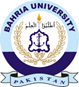 Bahria University, Lahore Campus <br> Machine Learning (LAB Journal 10)


#### By **Asad Ali**, **03-134202-013**

### **Lab Tasks**:
Download a classification dataset from Kaggle or UCI Machine Learning Repository. After preprocessing, implement different ensembling techniques such as bagging, boosting, and stacking of at least three different ML classifiers. Implement AdaBoost and XGBoost, and compare them with Gradient Boost. Compare the performances of each ensembling techniques and meta-learners in stacking. Analyze the improvement (if any) achieved through ensembling.



In [226]:
# Initial Libraries
import pandas as pd
import numpy as np
import kagglehub 
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [227]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/vscode/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1


In [228]:
# Loading Dataset
name = 'stroke_data.csv'
base = pd.read_csv(name)
base = pd.DataFrame(base)
print(base.head(2))

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   

   stroke  
0       1  
1       1  


In [229]:
# Information About DS
print(base.columns)
base = base.drop(columns=['id'])
column_names = base.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [230]:
print(base.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB
None


In [231]:
base.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [232]:
# Check Null Attr
base.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [233]:
# Group-based imputation (e.g., by gender and age group)
base['bmi'] = base.groupby(['gender', 'age'])['bmi'].transform(lambda x: x.fillna(x.mean()))
base = base.dropna()

In [234]:
# Categorical & Numerical Columns
num_cols = base.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = base.select_dtypes(include=['object']).columns.tolist()
num_cols.remove("stroke") # Removing Target Column so it doesn't get included

In [235]:
print(f"{num_cols}\n\n {cat_cols}")

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

 ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [236]:
print(base.head(5))

   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level        bmi   smoking_status  stroke  
0          Urban             228.69  36.600000  formerly smoked       1  
1          Rural             202.21  29.879487     never smoked       1  
2          Rural             105.92  32.500000     never smoked       1  
3          Urban             171.23  34.400000           smokes       1  
4          Rural             174.12  24.000000     never smoked       1  


In [237]:
# further classify categorical columns:

binary_cols = []
multi_cols = []

for col in cat_cols:
    unique_vals = base[col].dropna().unique()
    if len(unique_vals) == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"{binary_cols} \n\n {multi_cols}")

['ever_married', 'Residence_type'] 

 ['gender', 'work_type', 'smoking_status']


In [238]:
# Label encoding binary cols & one-hot encoding Multi-categorical columns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
for col in binary_cols:
    base[col] = le.fit_transform(base[col])

# one-hot enocding
base = pd.get_dummies(base, columns=multi_cols, drop_first=True).astype(int)


In [239]:
print(base.head(6))

   age  hypertension  heart_disease  ever_married  Residence_type  \
0   67             0              1             1               1   
1   61             0              0             1               0   
2   80             0              1             1               0   
3   49             0              0             1               1   
4   79             1              0             1               0   
5   81             0              0             1               1   

   avg_glucose_level  bmi  stroke  gender_Male  gender_Other  \
0                228   36       1            1             0   
1                202   29       1            0             0   
2                105   32       1            1             0   
3                171   34       1            0             0   
4                174   24       1            0             0   
5                186   29       1            1             0   

   work_type_Never_worked  work_type_Private  work_type_Self-employ

In [240]:
# base.to_csv('heart_clean.csv', index= False)

In [241]:
# Removing Outliers

from scipy import stats

z_scores = stats.zscore(base[num_cols])
abs_Z_score = abs(z_scores)
filtered_entries = (abs_Z_score < 3).all(axis=1)

base = base[filtered_entries]

In [242]:
print(base.head(5))

   age  hypertension  heart_disease  ever_married  Residence_type  \
1   61             0              0             1               0   
3   49             0              0             1               1   
5   81             0              0             1               1   
7   69             0              0             0               1   
8   59             0              0             1               0   

   avg_glucose_level  bmi  stroke  gender_Male  gender_Other  \
1                202   29       1            0             0   
3                171   34       1            0             0   
5                186   29       1            1             0   
7                 94   22       1            0             0   
8                 76   30       1            0             0   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
1                       0                  0                        1   
3                       0                  1          

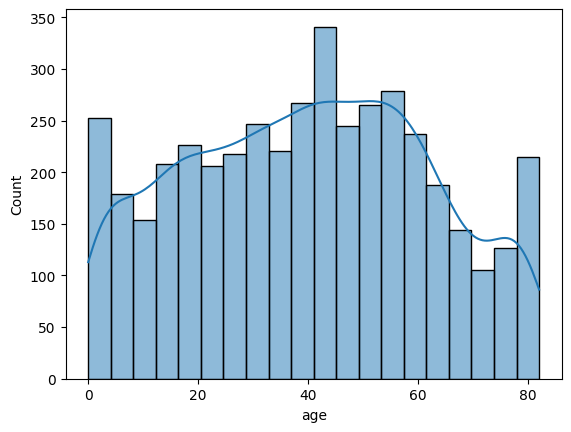

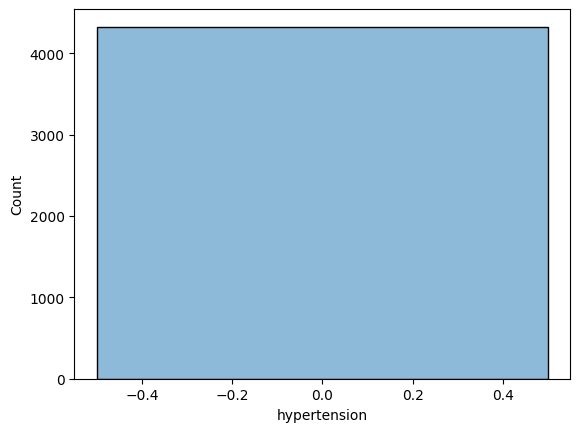

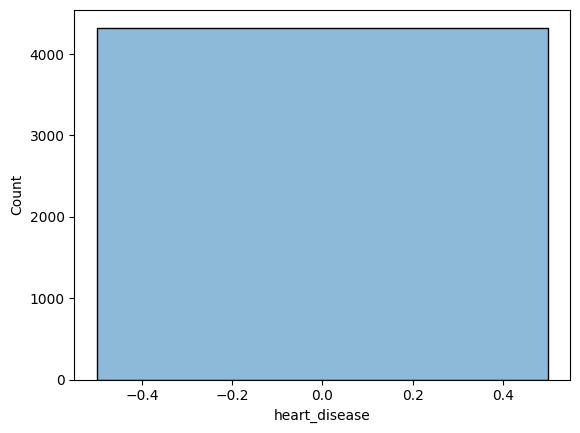

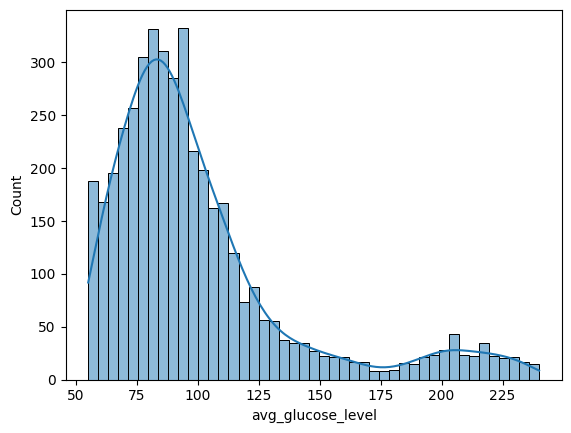

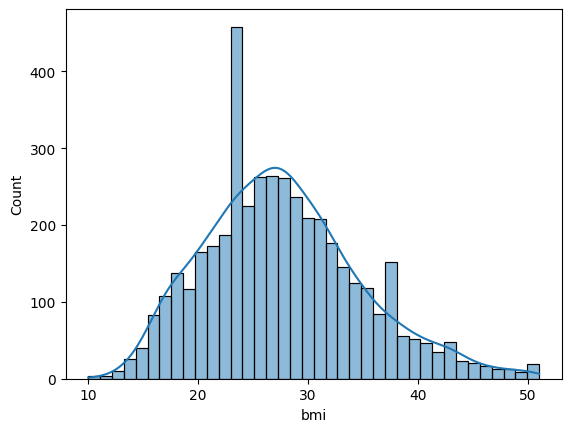

In [243]:
# Visualize the distribution of numerical cols
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.histplot(base[col], kde=True)
    plt.show()

In [244]:
# Scaling / normalization based on plots SC for bell curves & Min-Max for others
skewed_cols = ['hypertension', 'heart_disease']
normal_cols = [col for col in num_cols if col not in skewed_cols]

print(skewed_cols, "\n\n", normal_cols)

['hypertension', 'heart_disease'] 

 ['age', 'avg_glucose_level', 'bmi']


In [245]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc = StandardScaler()
mms = MinMaxScaler()

base[normal_cols] = sc.fit_transform(base[normal_cols])
base[skewed_cols] = mms.fit_transform(base[skewed_cols])

In [246]:

print(base.describe())
# print(p_ds.head(2))

                age  hypertension  heart_disease  ever_married  \
count  4.325000e+03        4325.0         4325.0   4325.000000   
mean  -3.942896e-17           0.0            0.0      0.614104   
std    1.000116e+00           0.0            0.0      0.486862   
min   -1.800318e+00           0.0            0.0      0.000000   
25%   -8.025008e-01           0.0            0.0      0.000000   
50%    1.389498e-02           0.0            0.0      1.000000   
75%    7.849354e-01           0.0            0.0      1.000000   
max    1.918818e+00           0.0            0.0      1.000000   

       Residence_type  avg_glucose_level           bmi       stroke  \
count     4325.000000       4.325000e+03  4.325000e+03  4325.000000   
mean         0.507283       1.577158e-16 -1.018581e-16     0.033757   
std          0.500005       1.000116e+00  1.000116e+00     0.180625   
min          0.000000      -1.168945e+00 -2.481102e+00     0.000000   
25%          0.000000      -6.292799e-01 -6.568577

In [247]:
# Saving a copy of ds
base.to_csv('stroke_processed.csv', index= False)

In [248]:
# Separation
X = base.drop(columns=['stroke'], axis=1)
y = base[['stroke']]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)


X_train:  (3460, 16)
X_test:  (865, 16)
y_train:  (3460, 1)
y_test:  (865, 1)


In [249]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#### **Bagging (Bootstrap Aggregating)**
Bagging trains multiple base models (typically of the same type) on random subsets of the data. Predictions are combined by averaging (regression) or voting (classification).

It reduces variance and helps in preventing overfitting.

In [250]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [251]:
# Prediction & Evaluation
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9664739884393063

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       838
           1       0.00      0.00      0.00        27

    accuracy                           0.97       865
   macro avg       0.48      0.50      0.49       865
weighted avg       0.94      0.97      0.95       865



#### **Boosting**:
Boosting builds models sequentially. Each new model tries to correct the errors made by the
previous models. It focuses on difficult examples and adapts over time.
It reduces bias and increases predictive power

In [252]:
from sklearn.ensemble import GradientBoostingClassifier
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier(random_state=42)

In [253]:
# Prediction & Evaluation
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9664739884393063

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       838
           1       0.00      0.00      0.00        27

    accuracy                           0.97       865
   macro avg       0.48      0.50      0.49       865
weighted avg       0.94      0.97      0.95       865



#### **Stacking**:
Stacking (stacked generalization) trains multiple diverse base models and uses a meta-model
to learn how to best combine their predictions.
It leverages the strengths of different models and usually outperforms bagging and boosting
in complex settings.


In [254]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [255]:
# Base learners
base_learners = [
 ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
 ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))
]


In [256]:
# Meta learner
meta_learner = LogisticRegression()

In [257]:
# Stacking Classifier
stack = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)
stack.fit(X_train, y_train)

/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(n_estimators=50,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=50,
                                                           random_state=42))],
                   final_estimator=LogisticRegression())

In [258]:
# Prediction & Evaluation
y_pred_stack = stack.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

Stacking Accuracy: 0.96878612716763

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       838
           1       0.00      0.00      0.00        27

    accuracy                           0.97       865
   macro avg       0.48      0.50      0.49       865
weighted avg       0.94      0.97      0.95       865



/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspaces/ml_labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
